In [1]:
import numpy as np

In [2]:
data_dir_asp  = './asp/'
data_dir_qzmc = '../Compare/4x1/U4/eta-1-to-compare-with-ASP'

In [3]:
dt_list = [0.1, 0.2, 0.5, 1.0]
n_dt = len(dt_list)
T_asps = np.linspace(1.0, 21.0, num=21)
n_asp = len(T_asps)
error_for_dt_list = np.zeros((n_dt,n_asp),dtype=float)
i_asp = 0
with open(data_dir_asp + 'dE_vs_T_for_dt.save','r') as file_:
    for line in file_:
        if not line.strip():
            continue
        if line.startswith('#'):
            continue
        ls = line.split()
        for i_dt in range(n_dt):
            error_for_dt_list[i_dt,i_asp] = float(ls[i_dt+1])
        #print(T_asps[i_asp],error_for_dt_list[:,i_asp])
        i_asp += 1

# dt = 0.5 
# T_asp = 9.0 for trotter
max_n_trotter_list = []
error_for_trotter_list = []

with open(data_dir_asp + 'dE_vs_n_trotter.save','r') as file_:
    for line in file_:
        if not line.strip():
            continue
        if line.startswith('#'):
            continue
        ls = line.split()
        max_n_trotter_list.append(float(ls[0]))
        error_for_trotter_list.append(float(ls[1]))

In [4]:
# read qzmc values
qzmc_max_time_list = []
qzmc_error_for_time_list = []

with open(data_dir_qzmc + '/dE_vs_evolution','r') as file_:
    for line in file_:
        if not line.strip():
            continue
        if line.startswith('#'):
            continue
        ls = line.split()
        qzmc_max_time_list.append(float(ls[0]))
        qzmc_error_for_time_list.append(float(ls[1]))

qzmc_max_n_trotter_list = []
qzmc_error_for_trotter_list = []

with open(data_dir_qzmc + '/dE_vs_n_trotter','r') as file_:
    for line in file_:
        if not line.strip():
            continue
        if line.startswith('#'):
            continue
        ls = line.split()
        qzmc_max_n_trotter_list.append(float(ls[0]))
        qzmc_error_for_trotter_list.append(float(ls[1]))

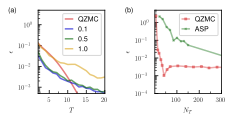

In [5]:
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('pdf','svg')
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
plt.rcParams.update({
    "text.usetex": True,  # LaTeX 사용
    "font.family": "Helvetica",
    "font.size": 7,  # 논문에 맞는 폰트 크기 설정 (보통 8~10pt)
})

cm    = 1.0/2.54
width_col = 8.6*cm
width = width_col 
height = width_col/2
plt.figure(figsize=(width,height),dpi=600)

marker_style_1  = dict(marker='', linestyle='-', color='tab:red', alpha=0.6,  fillstyle='full')
marker_style_1_1 = dict(marker='s', linestyle='-', color='tab:red', alpha=0.4,  fillstyle='full')
marker_style_2  = dict(marker='', linestyle='-', color='mediumblue', alpha=0.6,  fillstyle='full')
marker_style_3  = dict(marker='', linestyle='-', color='black', alpha=0.4,  fillstyle='full')
marker_style_4  = dict(marker='', linestyle='-', color='darkgreen', alpha=0.6,  fillstyle='full')
marker_style_4_1  = dict(marker='x', linestyle='-', color='darkgreen', alpha=0.4,  fillstyle='full')
marker_style_5  = dict(marker='', linestyle='-', color='goldenrod', alpha=0.6,  fillstyle='full')


axes = []
ax = plt.subplot2grid((1,2),(0,0))
axes.append(ax)
ax = plt.subplot2grid((1,2),(0,1))
axes.append(ax)

# (a) energies

axis = axes[0]

y_min    =  5e-4
y_max    =  5
##
x_min    =  2
x_max    =  20
#
axis.set_xlim(x_min,x_max)
axis.set_ylim(y_min,y_max)
# setup labels
#axes[0].text(-0.25,0.98,'(a)',transform=axes[0].transAxes)
axis.text(-0.45,0.975,r'(a)',transform=axis.transAxes)
#axes[0].text(0.5,-0.2,r'$R(\AA)$',transform=axes[0].transAxes)
axis.set_xlabel(r'$T$')
axis.set_ylabel(r'$\epsilon$')

axis.set_yscale('log')
# setup tics
axis.tick_params(axis='x', which='both', direction='in')
axis.tick_params(axis='y', which='both', direction='in')
axis.xaxis.set_major_locator(ticker.MultipleLocator(5))
#axis.xaxis.set_major_formatter('{:}')
axis.xaxis.set_minor_locator(ticker.MultipleLocator(2.5))

axis.set_yticks([1, 1e-1, 1e-2, 1e-3]) 

# plot
axis.plot(qzmc_max_time_list,qzmc_error_for_time_list, label='QZMC',  **marker_style_1)
axis.plot(T_asps,error_for_dt_list[0,:], label=r'0.1', markersize=2, **marker_style_2)
#axis.plot(T_asps,error_for_dt_list[1,:], label=r'0.2', markersize=2, **marker_style_3)
axis.plot(T_asps,error_for_dt_list[2,:], label=r'0.5', markersize=2, **marker_style_4)
axis.plot(T_asps,error_for_dt_list[3,:], label=r'1.0', markersize=2, **marker_style_5)

axis.legend(loc='upper right',handlelength=1)

# (b) norms

axis = axes[1]
#
y_min    =  5e-4
y_max    =  5
##
x_min    =  1
x_max    =  300
#
axis.set_xlim(x_min,x_max)
axis.set_ylim(y_min,y_max)
# setup labels
#axes[0].text(-0.25,0.98,'(a)',transform=axes[0].transAxes)
axis.text(-0.45,0.975,r'(b)',transform=axis.transAxes)
#axes[0].text(0.5,-0.2,r'$R(\AA)$',transform=axes[0].transAxes)
axis.set_xlabel(r'$N_T$')
axis.set_ylabel(r'$\epsilon$')

axis.set_yscale('log')
# setup tics
axis.tick_params(axis='x', which='both', direction='in')
axis.tick_params(axis='y', which='both', direction='in')
axis.xaxis.set_major_locator(ticker.MultipleLocator(100))
#axis.xaxis.set_major_formatter('{:}')
axis.xaxis.set_minor_locator(ticker.MultipleLocator(50))

axis.set_yticks([1, 1e-1, 1e-2, 1e-3, 1e-4]) 

# plot
axis.plot(qzmc_max_n_trotter_list,qzmc_error_for_trotter_list, label='QZMC', markersize=2, **marker_style_1_1)
axis.plot(max_n_trotter_list,error_for_trotter_list, label=r'ASP', markersize=2, **marker_style_4_1)

axis.legend(loc='upper right', handlelength=1)

#
plt.tight_layout()
#
plt.savefig('figS11.pdf')